<a href="https://colab.research.google.com/github/wataruhisano/MLB_salary_prediction/blob/main/mlb_salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLB 選手年俸予測 

## 目次

1. [環境セットアップ](#1-環境セットアップ)  
   ライブラリのインストール・インポート、Google Drive マウント、パス設定

2. [データ収集・前処理](#2-データ収集前処理)  
   年俸 CSV・Baseball Reference 成績・FanGraphs 指標の読み込みと DuckDB 格納

3. [データ結合](#3-データ結合)  
   重複チェック、受賞歴スコアの事前計算、3ソースの結合と重複排除

4. [探索的データ分析（EDA）](#4-探索的データ分析eda)  
   年俸分布の確認、外れ値処理、各指標のヒストグラム、相関行列

5. [特徴量エンジニアリング](#5-特徴量エンジニアリング)  
   VIF による多重共線性の評価、最終特徴量セットの選定、派生特徴量の作成

6. [モデル学習・評価](#6-モデル学習評価)  
   Random Forest・LightGBM・XGBoost の学習と MAE / MAPE / R² による比較

7. [モデル解釈・誤差分析](#7-モデル解釈誤差分析)  
   特徴量重要度・SHAP 値の可視化、予測誤差が大きい選手の分析

8. [データ保存](#8-データ保存)  
   DuckDB の Google Drive への同期

---
## 1. 環境セットアップ

分析に必要なライブラリをインストールし、各種モジュールをインポートします。  
また Google Drive をマウントして、データの読み書き先となるパスを設定します。  
再現性のため乱数シード（`SEED = 42`）を固定しています。

In [1]:
!pip install duckdb

In [2]:
import os
import pandas as pd
import duckdb
import re
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import shutil
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)


seed_everything(SEED)

In [3]:
# 1. マウント

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [4]:
# --- 1. 設定  ---
DRIVE_PATH = '/content/drive/My Drive/個人開発/MLB_DATA_PREDICT/data/'
LOCAL_DB_PATH = '/content/mlb_analytics.duckdb'
SALARY_CSV = os.path.join(DRIVE_PATH, 'mlb_salary_data.csv')


In [5]:
# 既存のDBがあればDriveからローカルにコピー（継続開発用）

if os.path.exists(os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb')):

    shutil.copy(os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb'), LOCAL_DB_PATH)

    print("Existing database copied from Drive to local.")

In [6]:
# DuckDB接続
con = duckdb.connect(LOCAL_DB_PATH)

---
## 2. データ収集・前処理

3つのデータソースを読み込み、DuckDB に格納します。

| テーブル | ソース | 内容 |
|---|---|---|
| `t_salary` | Kaggle (Salary Data) | 選手別年俸（2017〜2024）(2020は試合数が少ないため除く) |
| `t_stats` | Baseball Reference | 打撃・守備の基本成績 |
| `t_fg_stats` | FanGraphs | wOBA・xwOBA・wRC+ などの高度指標 |

名前の形式の整え、`$5,850,000` 形式の数値変換など、  
データ結合の前処理として必要なクリーニング関数もここで定義します。

In [7]:
# --- 2. データクリーニング関数の定義 ---
def clean_salary(x):
    """$5,850,000 のような文字列を数値に変換"""
    if isinstance(x, str):
        return float(re.sub(r'[$,]', '', x))
    return x

def clean_name(x):
    """Matt Wallner* のような名前末尾の記号を除去"""
    if isinstance(x, str):
        return re.sub(r'[*#]', '', x).strip()
    return x

In [8]:
# --- 3. Salaryデータの読み込みとDuckDB格納 ---
if os.path.exists(SALARY_CSV):
    salary_raw = pd.read_csv(SALARY_CSV, encoding='latin1')
    # クリーニング
    salary_raw['Salary_Numeric'] = salary_raw['Salary'].apply(clean_salary)
    salary_raw['Name_Clean'] = salary_raw['Name'].apply(clean_name)

    # DuckDBへテーブル作成
    con.execute("CREATE OR REPLACE TABLE t_salary AS SELECT * FROM salary_raw")
    print("Salary data loaded and stored in DuckDB.")
else:
    print("エラー: Salary CSVが見つかりません。")

Salary data loaded and stored in DuckDB.


In [9]:
# --- 4. 年度別Baseball Referenceデータの読み込み (2022-2024) ---
years = [2017,2018,2019,2021,2022,2023,2024]
all_stats_list = []

for year in years:
    # ファイルパス構築
    stats_file = os.path.join(DRIVE_PATH, f'{year}_stats.csv')

    if os.path.exists(stats_file):
        df = pd.read_csv(stats_file)
        df['Year'] = year
        # 提示された形式に基づき、Nameのクレンジング
        if 'Name' in df.columns:
            df['Name_Clean'] = df['Name'].apply(clean_name)
        else:

            df['Name_Clean'] = df.iloc[:, 1].apply(clean_name)

        all_stats_list.append(df)
        print(f"Loaded stats for {year}")

if all_stats_list:
    full_stats_df = pd.concat(all_stats_list)
    con.execute("CREATE OR REPLACE TABLE t_stats AS SELECT * FROM full_stats_df")
else:
    print("エラー: 年度別の統計データが見つかりません。")

Loaded stats for 2017
Loaded stats for 2018
Loaded stats for 2019
Loaded stats for 2021
Loaded stats for 2022
Loaded stats for 2023
Loaded stats for 2024


In [10]:
# --- 4.5 FanGraphsデータの読み込み (2022-2024) ---
# ファイル名が 'fg_stats_2022.csv' 等であると仮定
fg_years =  [2017,2018,2019,2021,2022, 2023, 2024]
all_fg_list = []

for year in fg_years:
    fg_file = os.path.join(DRIVE_PATH, f'fg_stats_{year}.csv') 
    if os.path.exists(fg_file):
        df_fg = pd.read_csv(fg_file)
        df_fg['Year'] = year

        # 名前列の特定とクレンジング
        if 'Name' in df_fg.columns:
            df_fg['Name_Clean'] = df_fg['Name'].apply(clean_name)
        else:
            df_fg['Name_Clean'] = df_fg.iloc[:, 0].str.replace(r'^\d+', '', regex=True).apply(clean_name)

        all_fg_list.append(df_fg)
        print(f"Loaded FanGraphs {year}")

if all_fg_list:
    full_fg_df = pd.concat(all_fg_list)
    # DuckDBへ格納 (既にある指標と重複を避けるためテーブル名を分ける)
    con.execute("CREATE OR REPLACE TABLE t_fg_stats AS SELECT * FROM full_fg_df")
else:
    print("エラー: FanGraphsデータが見つかりません。")

Loaded FanGraphs 2017
Loaded FanGraphs 2018
Loaded FanGraphs 2019
Loaded FanGraphs 2021
Loaded FanGraphs 2022
Loaded FanGraphs 2023
Loaded FanGraphs 2024


---
## 3. データ結合

3つのテーブルを選手名（小文字・トリム処理済み）と年度をキーに結合し、  
分析・モデリング用のデータフレーム `df_model` を作成します。

**重複チェック**  
まず BR と FanGraphs を結合した段階で、同一選手が複数行になっていないかを確認します。

**受賞歴スコアの事前計算（`t_career_awards`）**  
`t_stats` の Awards 列から MVP・シルバースラッガー・ゴールドグラブ・オールスターのフラグを立て、  
ウィンドウ関数で「過去5年間の受賞回数」を各年について集計します。  
これをメイン結合時に LEFT JOIN することで、選手の「ブランド価値」を特徴量として付与します。
Award列がない選手は０で埋めています。


In [11]:
# 結合して重複が出ている状態のDFを作成
df_model = con.execute("""
SELECT
    s.Name_Clean as s_name,
    f.Name_Clean as f_name,
    s.Year,
    s.Team
FROM t_stats s
JOIN t_fg_stats f
  ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(f.Name_Clean AS VARCHAR)))
 AND s.Year = f.Year
""").df()

# 重複している「名前と年のペア」を特定
dups = df_model[df_model.duplicated(subset=['s_name', 'Year'], keep=False)]

print(dups.sort_values(['s_name', 'Year']).head(20))

                s_name             f_name  Year Team
561        Adam Duvall        Adam Duvall  2021  2TM
562        Adam Duvall        Adam Duvall  2021  MIA
563        Adam Duvall        Adam Duvall  2021  ATL
520       Adam Frazier       Adam Frazier  2021  2TM
521       Adam Frazier       Adam Frazier  2021  PIT
522       Adam Frazier       Adam Frazier  2021  SDP
710  Andrew Benintendi  Andrew Benintendi  2022  2TM
711  Andrew Benintendi  Andrew Benintendi  2022  KCR
712  Andrew Benintendi  Andrew Benintendi  2022  NYY
244   Andrew McCutchen   Andrew McCutchen  2018  2TM
245   Andrew McCutchen   Andrew McCutchen  2018  SFG
246   Andrew McCutchen   Andrew McCutchen  2018  NYY
587      Anthony Rizzo      Anthony Rizzo  2021  2TM
588      Anthony Rizzo      Anthony Rizzo  2021  CHC
589      Anthony Rizzo      Anthony Rizzo  2021  NYY
277   Asdrúbal Cabrera   Asdrúbal Cabrera  2018  2TM
278   Asdrúbal Cabrera   Asdrúbal Cabrera  2018  NYM
279   Asdrúbal Cabrera   Asdrúbal Cabrera  201

シーズン途中に移籍した選手は移籍前のチームでの成績、移籍後でのチームの成績、それらを合わせた成績(2TM)の３つの成績があります。

In [12]:
# --- 5.1 過去実績スコアの事前計算 ---
award_query = """
CREATE OR REPLACE TEMP TABLE t_career_awards AS
WITH award_flags AS (
    SELECT
        Name_Clean,
        Year,
        -- 文字列からフラグ化（正規表現で数字が含まれていても検知可能に）
        CASE WHEN Awards LIKE '%MVP%' THEN 1 ELSE 0 END as mvp_f,
        CASE WHEN Awards LIKE '%SS%'  THEN 1 ELSE 0 END as ss_f,
        CASE WHEN Awards LIKE '%GG%'  THEN 1 ELSE 0 END as gg_f,
        CASE WHEN Awards LIKE '%AS%'  THEN 1 ELSE 0 END as as_f
    FROM t_stats
)
SELECT
    Name_Clean,
    Year,
    -- 去年から5年前までの合計
    SUM(mvp_f) OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as mvp_5yr,
    SUM(ss_f)  OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as ss_5yr,
    SUM(gg_f)  OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as gg_5yr,
    SUM(as_f)  OVER (PARTITION BY Name_Clean ORDER BY Year ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) as as_5yr
FROM award_flags;
"""
con.execute(award_query)

**メイン結合と重複排除**  
シーズン途中移籍選手について合算の成績(2TM)だけ取るために、PA（打席数）が最大の行を `ROW_NUMBER()` で選択し、同一選手・年度を1行に集約します。

In [13]:
# --- 5.2 メインのデータ結合 (実績スコアを追加 + 重複の強制排除) ---
query = """
WITH merged_data AS (
    SELECT
        s.*,
        ah.mvp_5yr,
        ah.ss_5yr,
        ah.gg_5yr,
        ah.as_5yr,
        (COALESCE(ah.mvp_5yr, 0) * 10 + COALESCE(ah.ss_5yr, 0) * 3 +
         COALESCE(ah.gg_5yr, 0) * 2 + COALESCE(ah.as_5yr, 0) * 1) as career_award_score,

        f.wOBA, f.xwOBA, f."wRC+", f.BsR, f.Off, f.Def, f.ISO, f.BABIP,
        f.AVG AS f_AVG, f.OBP AS f_OBP, f.SLG AS f_SLG, f."BB%", f."K%",
        f.WAR AS fWAR, f.HR AS f_HR,
        y.Salary_Numeric AS target_salary
    FROM t_stats s
    JOIN t_fg_stats f
      ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(f.Name_Clean AS VARCHAR)))
     AND s.Year = f.Year
    JOIN t_salary y
      ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(y.Name_Clean AS VARCHAR)))
     AND s.Year = y.Year
    LEFT JOIN t_career_awards ah
      ON trim(LOWER(CAST(s.Name_Clean AS VARCHAR))) = trim(LOWER(CAST(ah.Name_Clean AS VARCHAR)))
     AND s.Year = ah.Year
    WHERE y.Salary_Numeric > 0
)
SELECT * EXCLUDE(rn) FROM (
    SELECT *,
           -- 同じ名前・年度の中で、PA(打席数)が多い順に番号を振る
           ROW_NUMBER() OVER(PARTITION BY Name_Clean, Year ORDER BY PA DESC) as rn
    FROM merged_data
)
WHERE rn = 1  -- 重複があっても必ず1行だけを抽出
ORDER BY Year, Name_Clean
"""

df_model = con.execute(query).df()

# --- 以降の処理 ---

# Bref側のWARを WAR(bref) にリネームして区別
if 'WAR' in df_model.columns:
    df_model = df_model.rename(columns={'WAR': 'WAR(bref)'})

# FanGraphs側のWARを WAR(fg) にリネームして区別
if 'fWAR' in df_model.columns:
    df_model = df_model.rename(columns={'fWAR': 'WAR(fg)'})

# 重複列の削除と不要な列のドロップ
df_model = df_model.loc[:, ~df_model.columns.duplicated()]
cols_to_drop = [c for c in ['Player', 'Rk'] if c in df_model.columns]
df_model.drop(cols_to_drop, axis=1, inplace=True)

# 欠損値（過去実績がない若手など）を0埋め
award_cols = ['mvp_5yr', 'ss_5yr', 'gg_5yr', 'as_5yr', 'career_award_score']
df_model[award_cols] = df_model[award_cols].fillna(0)

# 最終確認
print(f"最終的なデータ件数: {len(df_model)}")

最終的なデータ件数: 854


重複した選手がいないか確認

In [14]:
# 名前と年でグルーピングして、2行以上あるものを探す
dups = df_model.groupby(['Name_Clean', 'Year']).size()
print(dups[dups > 1])

Series([], dtype: int64)


In [15]:
df_model.shape

(854, 45)

In [16]:
display(df_model[:].head())

,Age,Team,Lg,PA,Rbat,Rbaser,Rdp,Rfield,Rpos,RAA,...,ISO,BABIP,f_AVG,f_OBP,f_SLG,BB%,K%,WAR(fg),f_HR,target_salary
0,25,NYY,AL,678,58,-1,-1,9,-6,58,...,0.343173,0.356643,0.284133,0.421829,0.627306,0.187316,0.306785,8.694987,52,544500.0
1,28,CIN,NL,647,-1,-3,0,12,-6,2,...,0.231687,0.289673,0.248722,0.301391,0.480409,0.060278,0.262751,2.742537,31,577500.0
2,31,BAL,AL,635,12,2,-2,-14,4,2,...,0.180905,0.312364,0.284757,0.321767,0.465662,0.042520,0.177953,1.437265,26,16000000.0
3,37,LAA,AL,636,-21,0,-5,-1,-14,-41,...,0.145025,0.249480,0.241147,0.286164,0.386172,0.058176,0.146226,-1.808995,23,26000000.0
4,30,KCR,AL,629,-28,0,2,-10,8,-28,...,0.106845,0.290909,0.250417,0.271704,0.357262,0.023847,0.162162,0.474309,6,6500000.0


---
## 4. 探索的データ分析（EDA）

モデリングの前に、データの分布・品質・変数間の関係を把握します。

**主な確認項目**
- 年俸（`real_salary`）の分布形状：右裾が長い対数正規分布に近い形
- 最低年俸未満のレコード：年度別の最低年俸（2017: $535,000 〜 2024: $740,000）を基準に除去
- 各数値指標のヒストグラム：外れ値・歪みの確認
- 相関行列：0.9以上の強相関ペアを特定し、多重共線性のリスクを把握

In [17]:
# データの形状と型の構成を確認
print(f"データ件数: {len(df_model)} 行")
print(f"カラム数: {len(df_model.columns)} 列")

# 数値型の列とオブジェクト型の列を分ける
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
obj_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n数値指標 ({len(num_cols)}個): {num_cols}")
print(f"カテゴリ指標 ({len(obj_cols)}個): {obj_cols}")

# 欠損値が多い順に表示（上位10項目）
print("\n--- 欠損値が多い指標 TOP 10 ---")
print(df_model.isnull().sum().sort_values(ascending=False).head(10))

データ件数: 854 行
カラム数: 45 列

数値指標 (39個): ['Age', 'PA', 'Rbat', 'Rbaser', 'Rdp', 'Rfield', 'Rpos', 'RAA', 'WAA', 'Rrep', 'RAR', 'WAR(bref)', 'waaWL%', '162WL%', 'oWAR', 'dWAR', 'oRAR', 'Year', 'mvp_5yr', 'ss_5yr', 'gg_5yr', 'as_5yr', 'career_award_score', 'wOBA', 'xwOBA', 'wRC+', 'BsR', 'Off', 'Def', 'ISO', 'BABIP', 'f_AVG', 'f_OBP', 'f_SLG', 'BB%', 'K%', 'WAR(fg)', 'f_HR', 'target_salary']
カテゴリ指標 (6個): ['Team', 'Lg', 'Pos', 'Awards', 'Player-additional', 'Name_Clean']

--- 欠損値が多い指標 TOP 10 ---
Awards    474
Team        0
Lg          0
PA          0
Age         0
Rbaser      0
Rdp         0
Rfield      0
Rpos        0
RAA         0
dtype: int64


### 年俸の分布
年俸の分布は右裾が長い対数正規分布に近い形であるため、対数変換を利用します

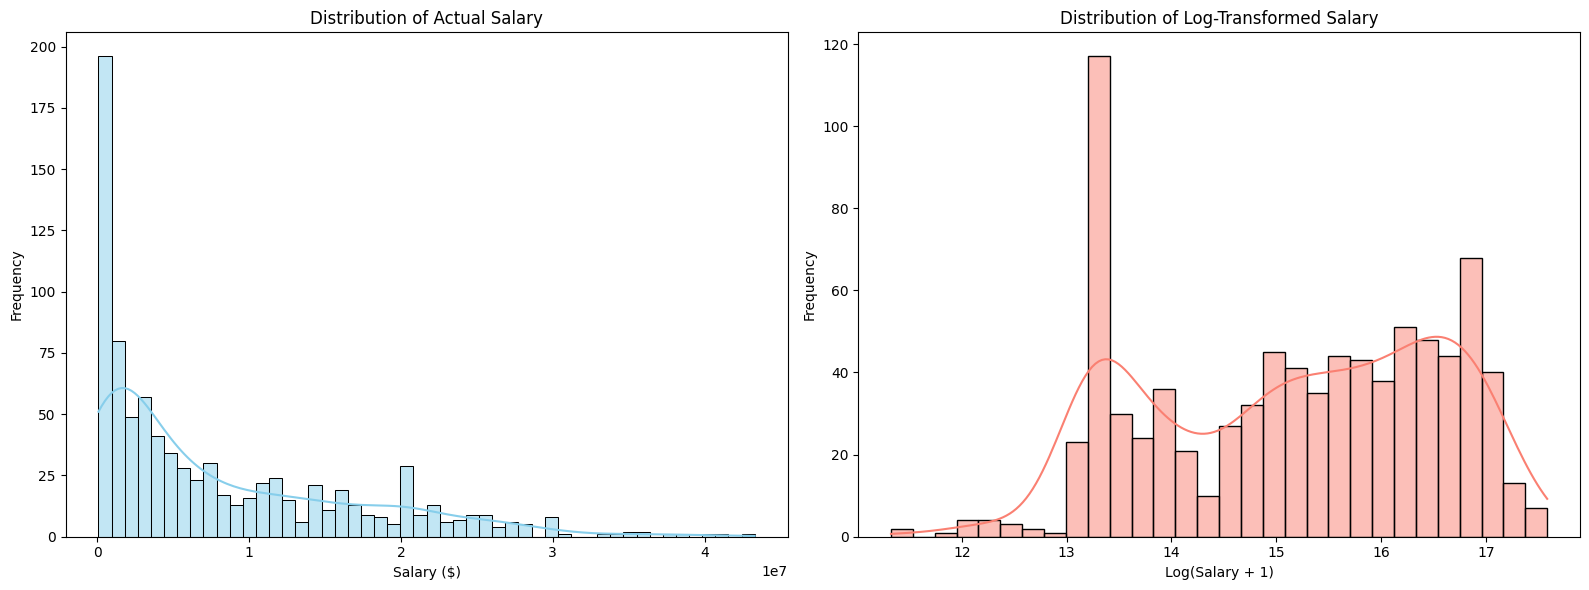

--- Salary Basic Statistics ---
count         854.000000
mean      8055585.695550
std       8559110.794946
min         82809.000000
25%       1026805.250000
50%       4500000.000000
75%      13000000.000000
max      43300000.000000
Name: target_salary, dtype: object


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# グラフの作成
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. 生の年俸分布（Actual Salary）
sns.histplot(df_model['target_salary'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Actual Salary')
ax[0].set_xlabel('Salary ($)')
ax[0].set_ylabel('Frequency')

# 2. 対数変換後の年俸分布（Log Salary）
sns.histplot(np.log1p(df_model['target_salary']), bins=30, kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Distribution of Log-Transformed Salary')
ax[1].set_xlabel('Log(Salary + 1)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 基本統計量の確認
print("--- Salary Basic Statistics ---")
print(df_model['target_salary'].describe().apply(lambda x: format(x, 'f')))

### 低年俸選手の除外


最低年俸以下の選手は日割り計算の合計が表示されているものと思われるので除外します

In [19]:
print(df_model[df_model['target_salary'] < 740000][['Name_Clean', 'target_salary', 'PA']])

            Name_Clean  target_salary   PA
0          Aaron Judge       544500.0  678
1          Adam Duvall       577500.0  647
5         Alex Bregman       539400.0  626
8    Andrew Benintendi       549000.0  658
13           Ben Gamel       464757.0  550
..                 ...            ...  ...
727      Triston Casas       732500.0  502
736     Zach McKinstry       734500.0  518
756   Bryan De La Cruz       247740.0  622
764  Christopher Morel       259812.0  611
807        Luis Arraez       592796.0  672

[172 rows x 3 columns]


In [20]:
# 年度別最低年俸（インフレ調整と同じ定数を使いまわす）
MIN_SALARY_BY_YEAR = {
    2017: 535000,
    2018: 545000,
    2019: 555000,
    2021: 570500,  # 2020はコロナで除外済み
    2022: 700000,
    2023: 720000,
    2024: 740000,
}

# 各行の最低年俸閾値を年度から引いてくる
df_model['min_salary'] = df_model['Year'].map(MIN_SALARY_BY_YEAR)

# その年の最低年俸未満を除外
df_model_cleaned = df_model[
    df_model['target_salary'] >= df_model['min_salary']
].copy()

print(f"除去前のデータ件数: {len(df_model)}件")
print(f"除去後のデータ件数: {len(df_model_cleaned)}件")
print(f"除去された人数: {len(df_model) - len(df_model_cleaned)}人")

除去前のデータ件数: 854件
除去後のデータ件数: 824件
除去された人数: 30人


年俸をそのまま使うと年度間のインフレ（最低年俸が2017年の$535,000から2024年の$740,000まで上昇）の影響を受けるため、
各年の最低年俸を基準に実質値（`salary_real`）へ変換

In [21]:
BASE_YEAR = 2024  # 基準年

# 調整係数を計算（基準年の最低年俸 ÷ その年の最低年俸）
df_model_cleaned['inflation_factor'] = df_model_cleaned['Year'].map(
    lambda y: MIN_SALARY_BY_YEAR[BASE_YEAR] / MIN_SALARY_BY_YEAR[y]
)

# 実質年俸を作成
df_model_cleaned['salary_real'] = (
    df_model_cleaned['target_salary'] * df_model_cleaned['inflation_factor']
)

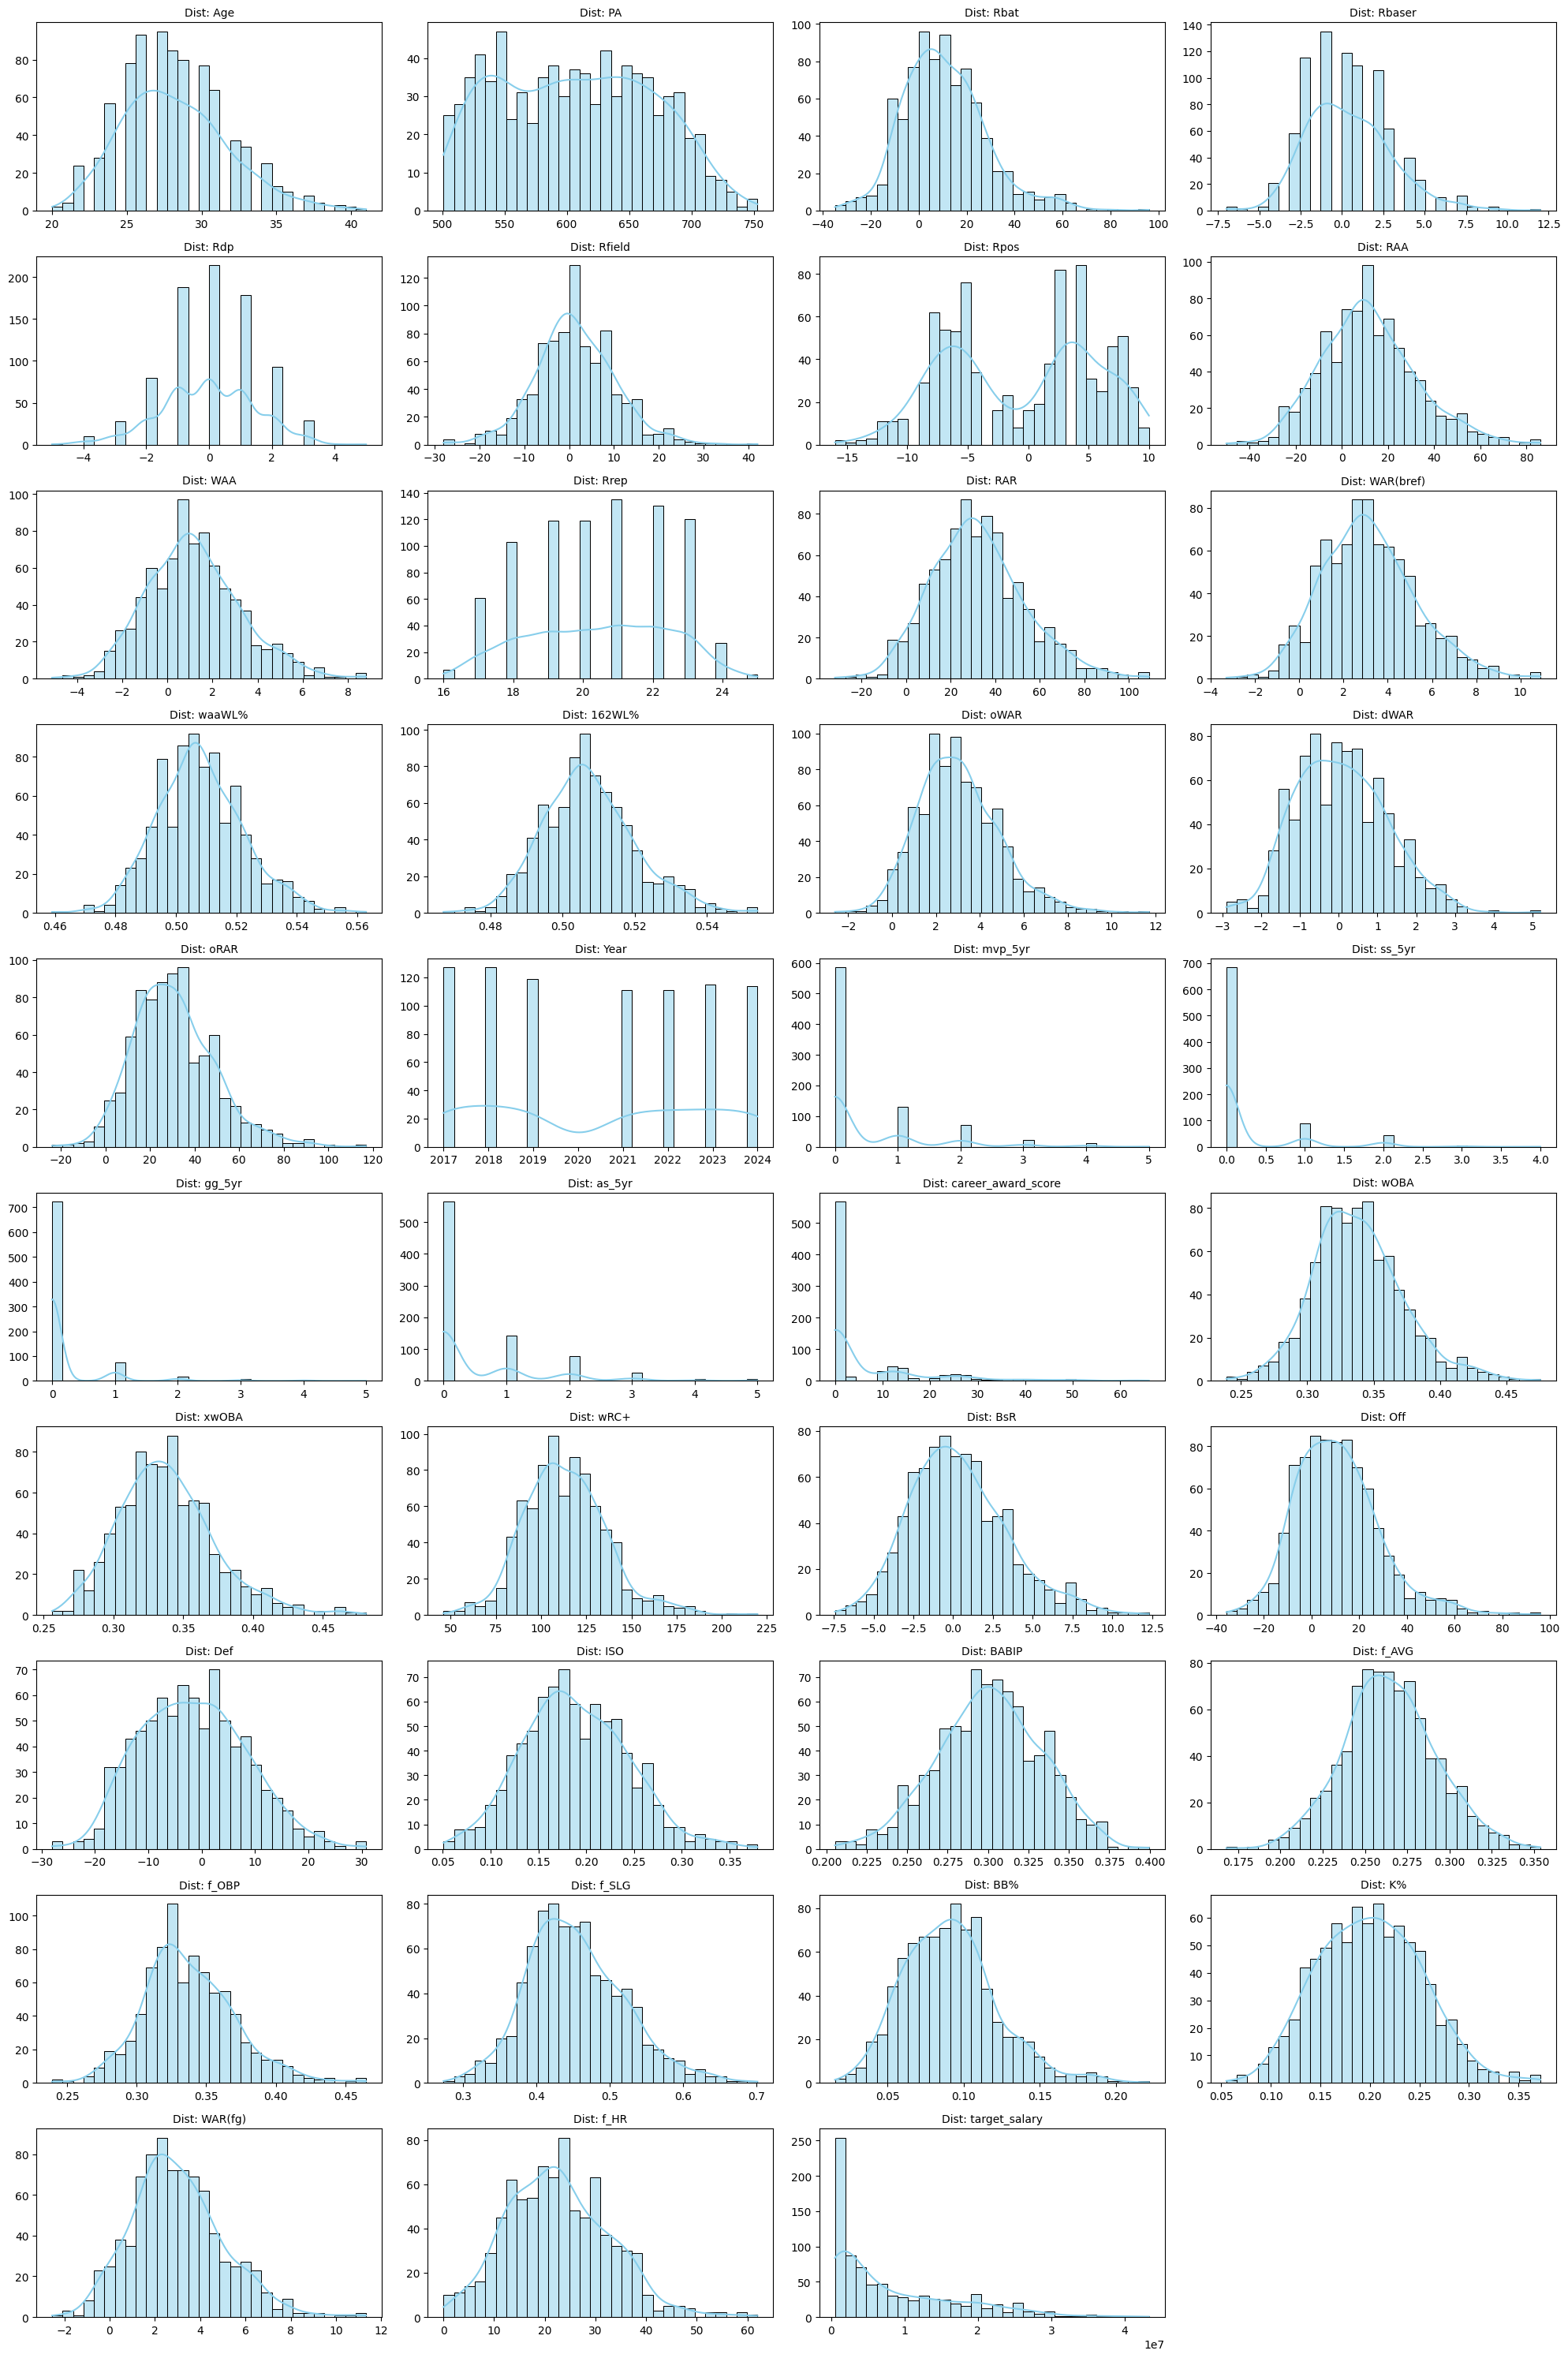

In [22]:
# 数値データのみ抽出
data_num = df_model_cleaned[num_cols]

# 指標の数に合わせてグリッドを自動計算
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data_num[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Dist: {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# 余った空白グラフを消す
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 相関分析

In [23]:
# 1. 全数値指標の相関行列
full_corr = df_model_cleaned.select_dtypes(include=[np.number]).corr()

# 2. 相関が0.9以上のペアを抽出
high_corr_list = []
for i in range(len(full_corr.columns)):
    for j in range(i):
        coef = full_corr.iloc[i, j]
        if abs(coef) > 0.9:
            high_corr_list.append({
                'Feature 1': full_corr.columns[i],
                'Feature 2': full_corr.columns[j],
                'Correlation': coef
            })

# 結果を表示
df_high_corr = pd.DataFrame(high_corr_list)
print("--- 相関が0.9以上のペア（ ---")
print(df_high_corr.sort_values(by='Correlation', ascending=False))

--- 相関が0.9以上のペア（ ---
             Feature 1      Feature 2  Correlation
20                oRAR           oWAR     0.998686
6            WAR(bref)            RAR     0.997221
0                  WAA            RAA     0.996474
5            WAR(bref)            WAA     0.996331
11              162WL%            RAA     0.995877
2                  RAR            RAA     0.995708
7               waaWL%            RAA     0.995008
3                  RAR            WAA     0.994615
12              162WL%            WAA     0.993186
15              162WL%         waaWL%     0.992168
8               waaWL%            WAA     0.991941
4            WAR(bref)            RAA     0.991714
13              162WL%            RAR     0.991413
14              162WL%      WAR(bref)     0.988066
21  career_award_score        mvp_5yr     0.987863
9               waaWL%            RAR     0.987394
10              waaWL%      WAR(bref)     0.983839
23                wRC+           Rbat     0.982383
44        

---
## 5. 特徴量エンジニアリング

相関分析で見えた多重共線性を、VIF（分散インフレーション係数）で定量的に評価します。  
VIF が高い指標を段階的に除外し、情報の重複が少ない特徴量セットを決定します。

**最終特徴量セット**  
`Age`, `is_veteran`, `PA`, `WAR(bref)`, `wRC+`, `BB%`, `K%`, `Def`, `BsR`, `career_award_score`  
＋ カテゴリ変数：`Team`, `Pos_Group`（ダミー変数化）

**派生特徴量**
- `is_veteran`：31歳以上をベテランとするバイナリフラグ
- `Pos_Group`：守備位置を `Catcher / First Base / Second Base / Third Base / Shortstop / Outfield / DH` に分類

**目的変数**  
年俸をそのまま使うと年度間のインフレ（最低年俸が2017年の$535,000から2024年の$740,000まで上昇）の影響を受けるため、
各年の最低年俸を基準に実質値（`salary_real`）へ変換してから `log1p` 変換を適用します。

### VIFスコアによる定量的評価

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 診断対象にする特徴量
vif_target_features = [
    'Age', 'PA', 'WAR(fg)', 'WAR(bref)', 'wRC+', 'xwOBA',
    'ISO', 'BB%', 'K%', 'f_AVG', 'f_HR', 'Def', 'BsR', 'Rpos','career_award_score'
]

X_vif = df_model_cleaned[vif_target_features].dropna()

# VIFの計算
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n--- VIFスコア ---")
print(vif_data.sort_values(by='VIF', ascending=False))


--- VIFスコア ---
               feature          VIF
4                 wRC+  1049.831198
5                xwOBA   458.960332
9                f_AVG   429.534995
6                  ISO   254.668188
1                   PA   150.211041
10                f_HR   122.504350
2              WAR(fg)   121.014672
0                  Age    81.556480
7                  BB%    29.220140
8                   K%    24.906771
3            WAR(bref)    24.714577
11                 Def    10.267773
13                Rpos     2.733858
12                 BsR     2.540840
14  career_award_score     1.782973


In [25]:
# 限界まで削ぎ落としたリスト
vif_final_features = [
    'Age',       # 年齢
    'PA',        # 出場機会
    'WAR(bref)', # 総合貢献度
    'wRC+',      # 打撃の質
    'BB%',       # 選球眼
    'K%',        # コンタクト能力
    'Def',       # 守備力
    'BsR',      # 走塁
    'career_award_score'

]

# 再度VIFを確認するためのコード
X_vif_final = df_model_cleaned[vif_final_features].dropna()
vif_data_final = pd.DataFrame()
vif_data_final["feature"] = X_vif_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_vif_final.values, i) for i in range(len(X_vif_final.columns))]
print(vif_data_final.sort_values(by='VIF', ascending=False))

              feature         VIF
3                wRC+  107.989332
1                  PA   67.545633
0                 Age   56.036234
2           WAR(bref)   17.259792
5                  K%   15.845518
4                 BB%   14.643719
6                 Def    1.875924
8  career_award_score    1.543510
7                 BsR    1.395265


ヒートマップを作成し、最終確認

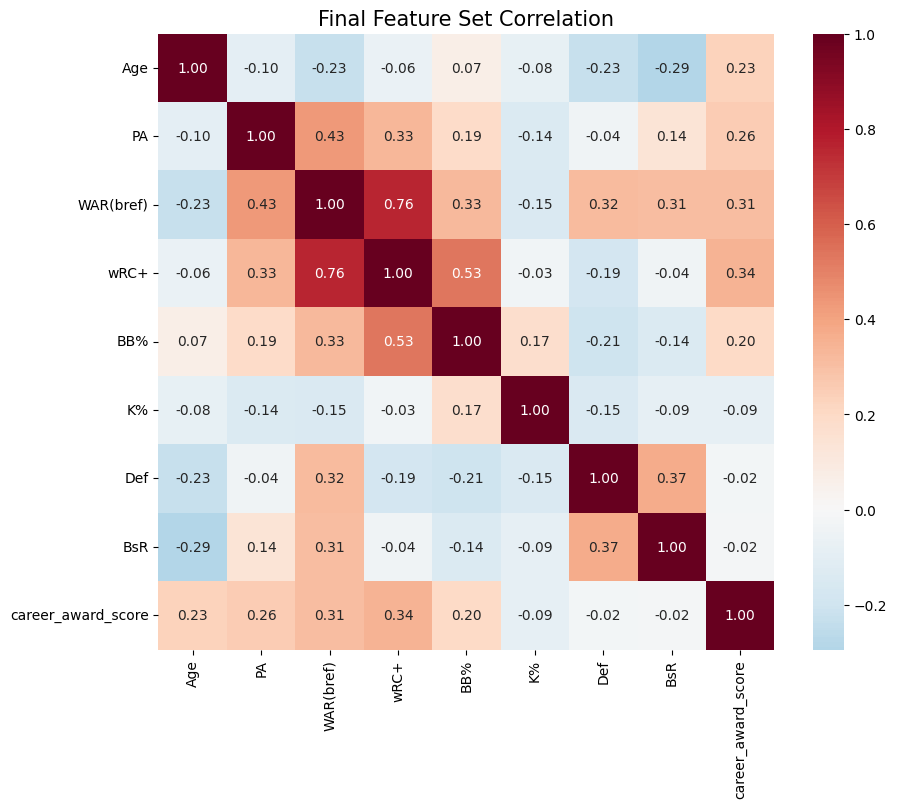

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_model_cleaned[vif_final_features].corr(),
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            square=True)

plt.title('Final Feature Set Correlation', fontsize=15)
plt.show()

### `salary_real`と各特徴量の相関

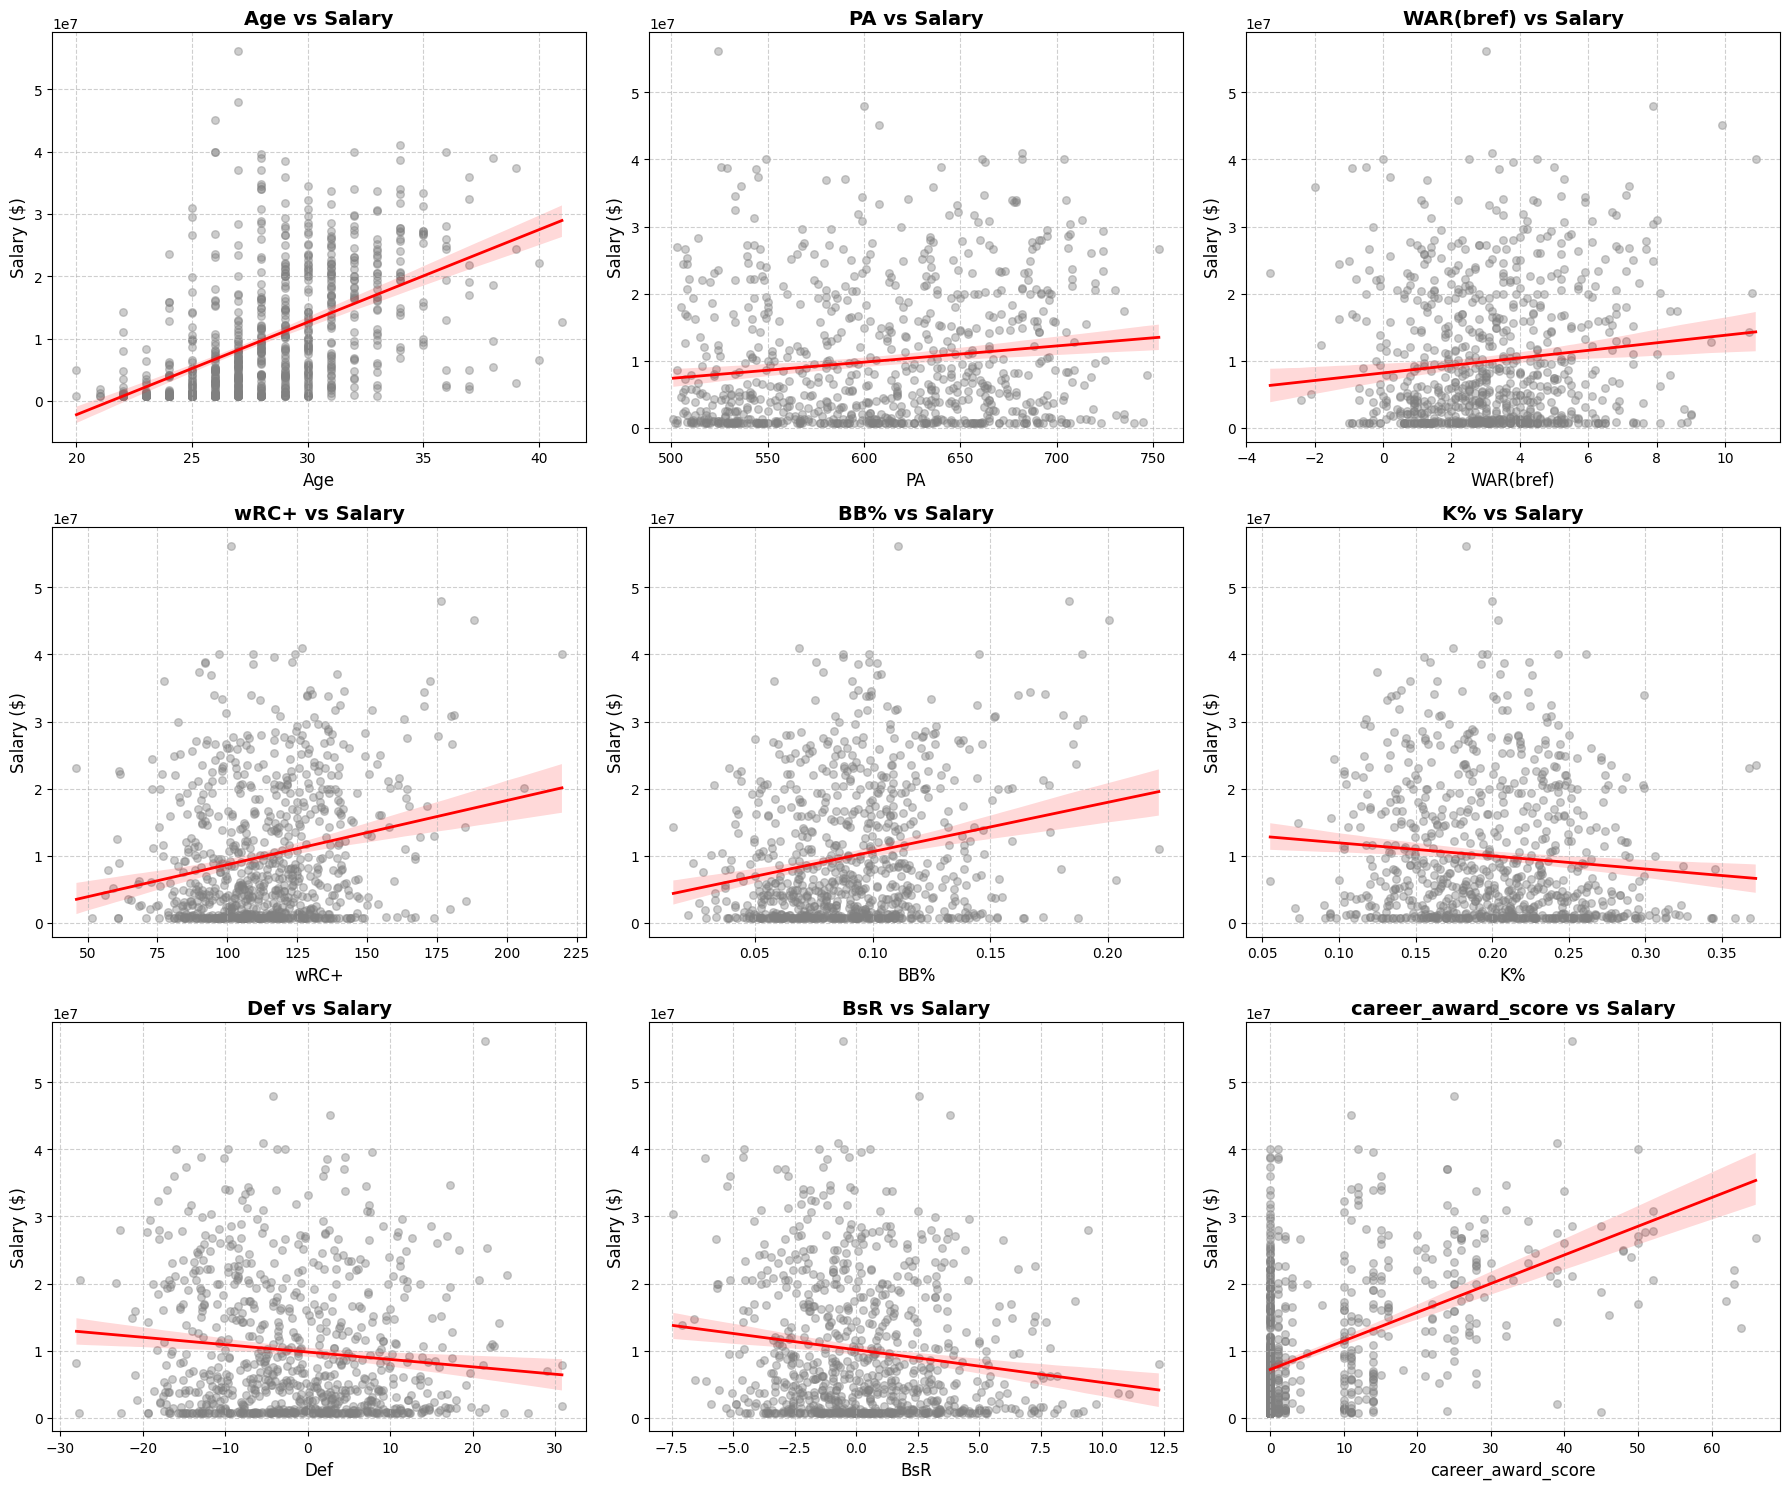

In [27]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# グリッドのサイズを計算
n_features = len(vif_final_features)
n_cols = 3 
n_rows = math.ceil(n_features / n_cols)

# プロットの作成
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(vif_final_features):
    # regplotで散布図と回帰直線を描画
    sns.regplot(data=df_model_cleaned, x=col, y='salary_real', ax=axes[i],
                scatter_kws={'alpha': 0.4, 's': 30, 'color': 'gray'},
                line_kws={'color': 'red', 'lw': 2})

    axes[i].set_title(f'{col} vs Salary', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Salary ($)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 余った空白のプロットを削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 年齢と`salary_real`,warの関係

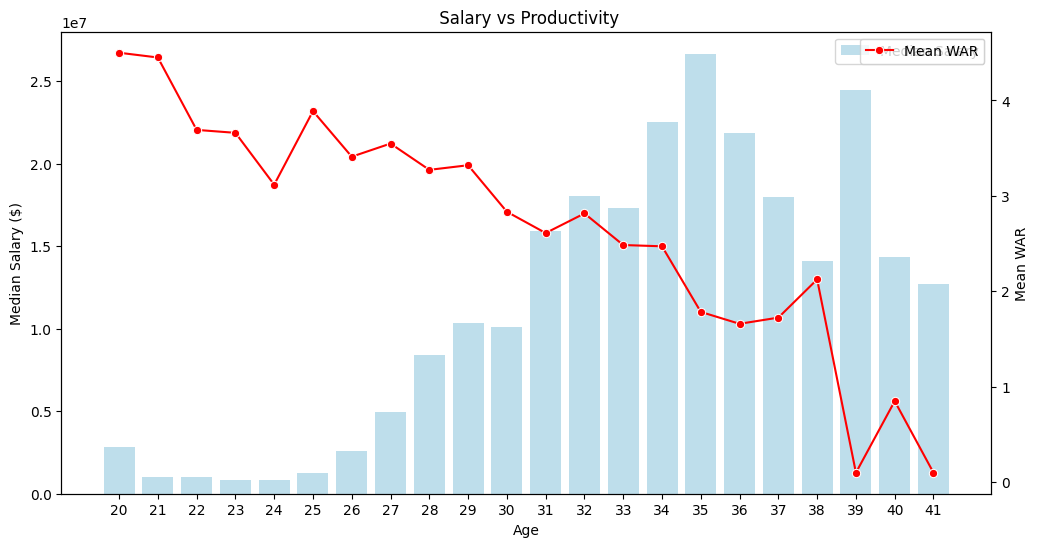

In [28]:
# 年齢ごとの年俸中央値と平均WARを算出
age_stats = df_model_cleaned.groupby('Age').agg({
    'salary_real': 'median',
    'WAR(bref)': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 年俸の推移（棒グラフ）
sns.barplot(data=age_stats, x='Age', y='salary_real', ax=ax1, color='skyblue', alpha=0.6, label='Median Salary')
ax1.set_ylabel('Median Salary ($)')

# WARの推移（折れ線グラフ）
ax2 = ax1.twinx()
sns.lineplot(data=age_stats, x=age_stats.index, y='WAR(bref)', ax=ax2, color='red', marker='o', label='Mean WAR')
ax2.set_ylabel('Mean WAR')

plt.title(' Salary vs Productivity')
plt.show()

31歳以上になると給料は伸びるが成績は全体的に伸びなくなる。これは長期契約を結んでいる選手が多いため、成績が落ちても年俸が維持されるからと考えられます。これを考慮するため以下のフラグを作成します

In [29]:
# 31歳以上をベテランとするフラグの作成
df_model_cleaned['is_veteran'] = (df_model_cleaned['Age'] >= 31).astype(int)

### 守備位置と年俸の関係

In [30]:
import re

def categorize_pos_bref(pos):
    pos = str(pos).upper()

    # 1. 捕手 (2)
    if '2' in pos: return 'Catcher'

    # 2. 一塁手 (3)
    if '3' in pos: return 'First Base'

    # 3. 二塁手 (4)
    if '4' in pos: return 'Second Base'

    # 4. 三塁手 (5)
    if '5' in pos: return 'Third Base'

    # 5. 遊撃手 (6)
    if '6' in pos: return 'Shortstop'

    # 6. 外野手 (7:LF, 8:CF, 9:RF)
    if any(n in pos for n in ['7', '8', '9']): return 'Outfield'

    # 7. 指名打者 (D)
    if 'D' in pos: return 'DH'

    return 'Other'

# 適用
df_model_cleaned['Pos_Group'] = df_model_cleaned['Pos'].apply(categorize_pos_bref)

# 件数確認
print(df_model_cleaned['Pos_Group'].value_counts())

Pos_Group
Outfield       252
First Base     221
Second Base    135
Shortstop      102
Third Base      69
Catcher         38
DH               7
Name: count, dtype: int64


/tmp/ipykernel_10626/1859720530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_cleaned, x='Pos_Group', y='salary_real', palette='Set2', showfliers=False)


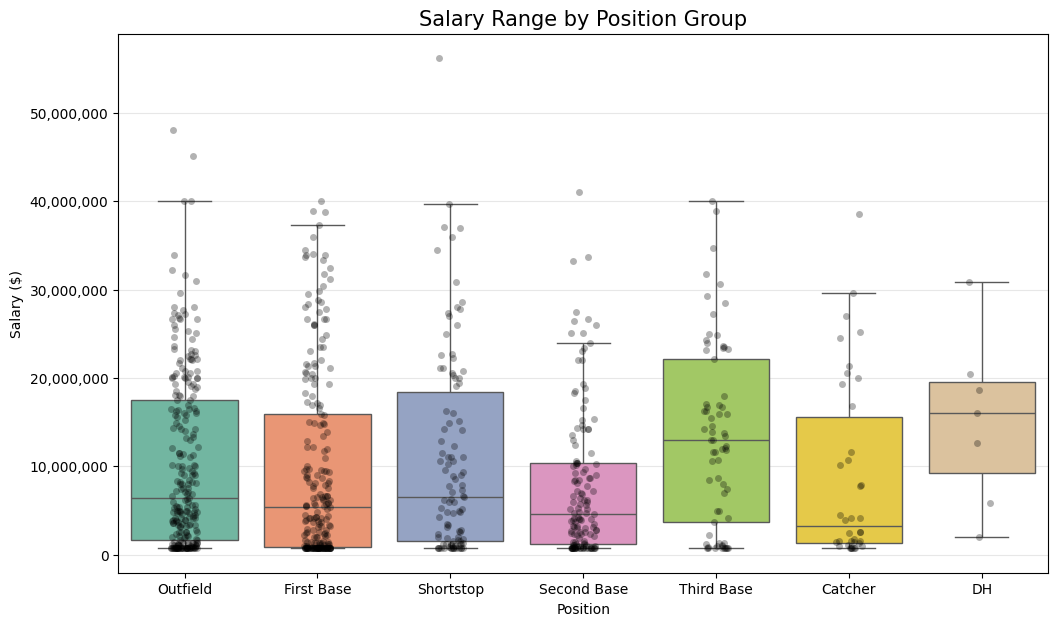

In [31]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=df_model_cleaned, x='Pos_Group', y='salary_real', palette='Set2', showfliers=False)
sns.stripplot(data=df_model_cleaned, x='Pos_Group', y='salary_real', color='black', alpha=0.3, jitter=True)

plt.title('Salary Range by Position Group', fontsize=15)
plt.ylabel('Salary ($)')
plt.xlabel('Position')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(axis='y', alpha=0.3)
plt.show()

中央値では、DHと三塁手が特に高い傾向が見られます。セカンドとキャッチャーは全体的に低く抑えられています。

### 所属チームと年俸の関係

/tmp/ipykernel_10626/1386297666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_cleaned, x='Team', y='salary_real', order=team_order, palette='vlag')


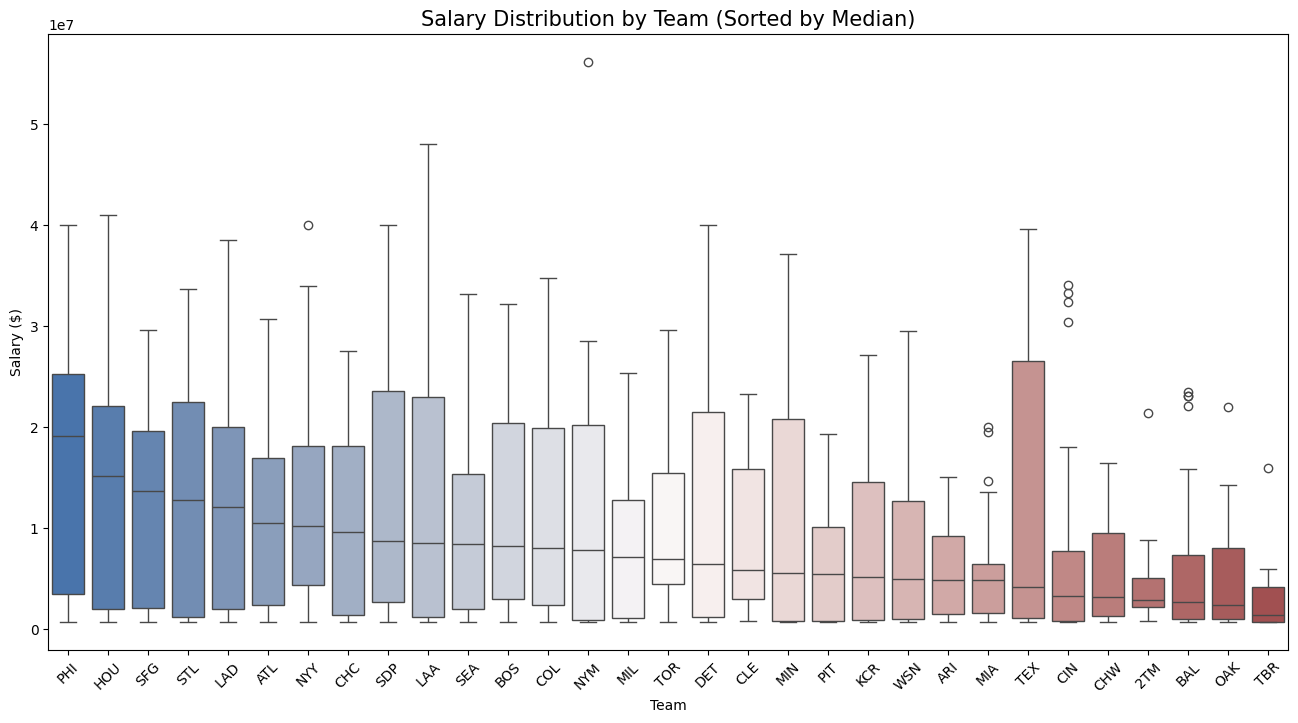

In [32]:
plt.figure(figsize=(16, 8))

# チームごとの中央値でソート
team_order = df_model_cleaned.groupby('Team')['salary_real'].median().sort_values(ascending=False).index

sns.boxplot(data=df_model_cleaned, x='Team', y='salary_real', order=team_order, palette='vlag')
plt.xticks(rotation=45)
plt.title('Salary Distribution by Team (Sorted by Median)', fontsize=15)
plt.ylabel('Salary ($)')
plt.show()

チームによる年俸の差が大きいことがわかります。

In [33]:
final_numeric_features = [
    'Age', 'is_veteran', 'PA', 'WAR(bref)', 'wRC+', 'BB%', 'K%', 'Def', 'BsR', 'career_award_score'
]

# カテゴリ変数（チームとポジション）
final_category_features = ['Team', 'Pos_Group']



---
## 6. モデル学習・評価

3つのアンサンブル学習モデルを比較します。  
目的変数（年俸）は `log1p` 変換してから学習し、評価時に `expm1` で元のスケールに戻します。

| モデル | 特徴 |
|---|---|
| Random Forest | バギングによる過学習抑制、特徴量重要度の解釈が容易 |
| LightGBM | 高速な勾配ブースティング、葉単位の分割 |
| XGBoost | 正則化付き勾配ブースティング、SHAP との親和性が高い |

年度順にソートしたうえで TimeSeriesSplit（5分割）による交差検証を行います。
「過去データで学習 → 未来年度で評価」という現実の予測状況に沿った評価方法です。
評価指標は MAE・MAPE・R² の平均値と標準偏差で比較します。

In [34]:
# 3. ダミー変数化（drop_first=False で全カテゴリを保持）

X = df_model_cleaned[final_numeric_features + final_category_features]
X_final = pd.get_dummies(X, columns=['Team', 'Pos_Group'], drop_first=False)

y = np.log1p(df_model_cleaned['salary_real'])

In [35]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 年度順にソート（TimeSeriesSplitの前提）
sort_idx = df_model_cleaned.sort_values('Year').index
X_final = X_final.loc[sort_idx]
y       = y.loc[sort_idx]

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_results = {
    "Random Forest": {"MAE": [], "MAPE": [], "R2": []},
    "LightGBM":      {"MAE": [], "MAPE": [], "R2": []},
    "XGBoost":       {"MAE": [], "MAPE": [], "R2": []},
}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_final), start=1):
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx],       y.iloc[test_idx]

    # 各Foldでどの年度がテストになっているか確認
    test_years = df_model_cleaned.loc[X_test.index, 'Year'].unique()
    print(f"\n--- Fold {fold} / {N_SPLITS}  テスト年度: {sorted(test_years)} ---")

    # Random Forest
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model_rf.fit(X_train, y_train)
    pred_rf = model_rf.predict(X_test)

    # LightGBM
    model_lgb = LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, n_jobs=-1)
    model_lgb.fit(X_train, y_train)
    pred_lgb = model_lgb.predict(X_test)

    # XGBoost
    model_xgb = XGBRegressor(objective='reg:squarederror', eval_metric='rmse', random_state=42)
    model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    pred_xgb = model_xgb.predict(X_test)

    for name, pred_log in [("Random Forest", pred_rf), ("LightGBM", pred_lgb), ("XGBoost", pred_xgb)]:
        actual = np.expm1(y_test)
        pred   = np.expm1(pred_log)
        cv_results[name]["MAE"].append(mean_absolute_error(actual, pred))
        cv_results[name]["MAPE"].append(mean_absolute_percentage_error(actual, pred) * 100)
        cv_results[name]["R2"].append(r2_score(y_test, pred_log))

# 最終Foldのモデル・データが後続セル（SHAP・残差分析）にそのまま使われる


--- Fold 1 / 5  テスト年度: [np.int64(2018), np.int64(2019)] ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 342
[LightGBM] [Info] Number of data points in the train set: 139, number of used features: 11
[LightGBM] [Info] Start training from score 15.389493
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

In [36]:
print("=" * 70)
print("  MLB Salary Prediction: TimeSeriesSplit CV Results (5-Fold)")
print("=" * 70)

summary_rows = []
for name, metrics in cv_results.items():
    summary_rows.append({
        "Model":     name,
        "MAE mean":  f"${np.mean(metrics['MAE']):,.0f}",
        "MAE std":   f"±${np.std(metrics['MAE']):,.0f}",
        "MAPE mean": f"{np.mean(metrics['MAPE']):.2f}%",
        "R2 mean":   f"{np.mean(metrics['R2']):.4f}",
    })

print(pd.DataFrame(summary_rows).to_string(index=False))
print("-" * 70)

  MLB Salary Prediction: TimeSeriesSplit CV Results (5-Fold)
        Model   MAE mean   MAE std MAPE mean R2 mean
Random Forest $4,956,555 ±$662,566   103.60%  0.5286
     LightGBM $5,262,755 ±$851,240   116.50%  0.4752
      XGBoost $5,500,757 ±$666,481   124.69%  0.4097
----------------------------------------------------------------------


---
## 7. モデル解釈・誤差分析

予測精度の数値だけでなく、「なぜそう予測したか」を可視化します。

**分析の流れ**
1. **特徴量重要度**（Random Forest）：どの指標が全体的に予測に効いているか
2. **残差分析**：年俸帯別（〜$2M / $2M〜$10M / $10M〜$20M / $20M〜）の予測誤差の偏りを確認
3. **誤差上位選手**：絶対誤差が大きい選手を特定し、過大・過小評価の原因を考察
4. **SHAP Waterfall**（XGBoost）：誤差上位10選手それぞれについて、どの特徴量が予測値を押し上げ・押し下げたかを個別に可視化

/tmp/ipykernel_10626/1837320197.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')


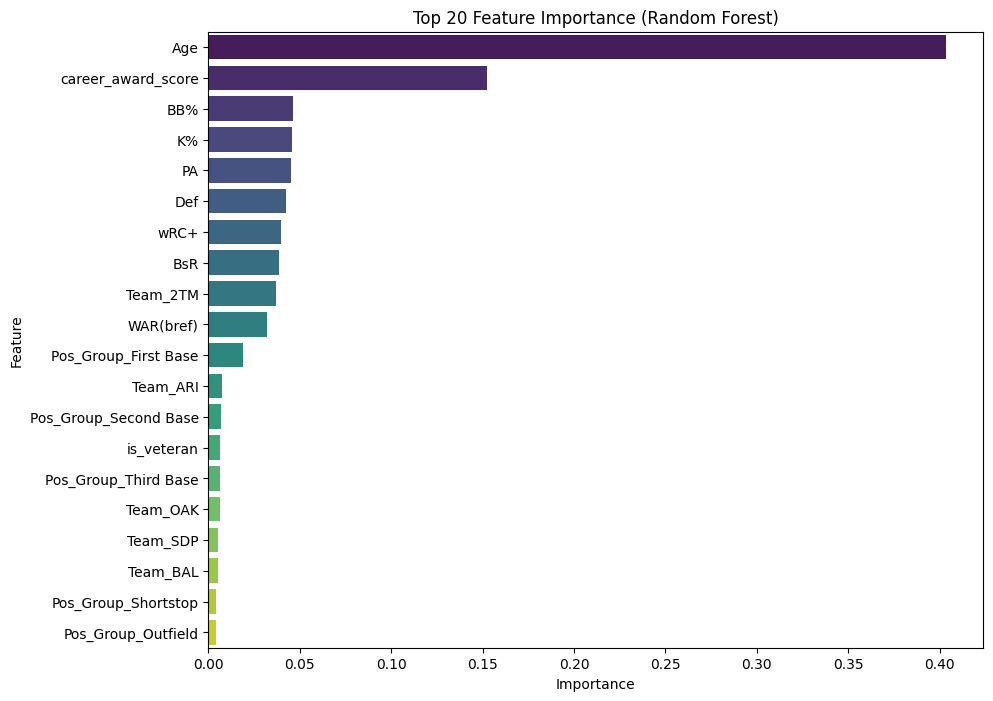

In [37]:
# Random Forest の重要度を可視化
import pandas as pd
import matplotlib.pyplot as plt

# model は学習済みの RandomForestRegressor
importances = model_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 上位20個を表示
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='viridis')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.show()

一番重要な特徴量は年齢であることがわかります。これは、MLBで自由に契約できるのがサービスタイム（実際にアクティブロースターに登録された期間）が６年たってからであることが原因として挙げられそうです。若い選手は実績が少ない選手が多いうえに、活躍しても制度上低年俸に抑えられるので年俸が低い傾向にあります。

また二番目に大きいcareer_award_scoreは 過去5年の受賞歴をポイント化（MVP×10 / SS×3 / GG×2 / AS×1）した指標です。このポイントが高い選手は、よりいい条件で長期契約を結んでいると考えられます。この指標を導入することで、特に高年俸選手の残差を減らすことができました。

一番影響が大きいと考えていたWARは、他の特徴量に比べて影響は大きくありませんでした。

/tmp/ipykernel_10626/4256285141.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='Salary_Range', y='Residual', palette='vlag')


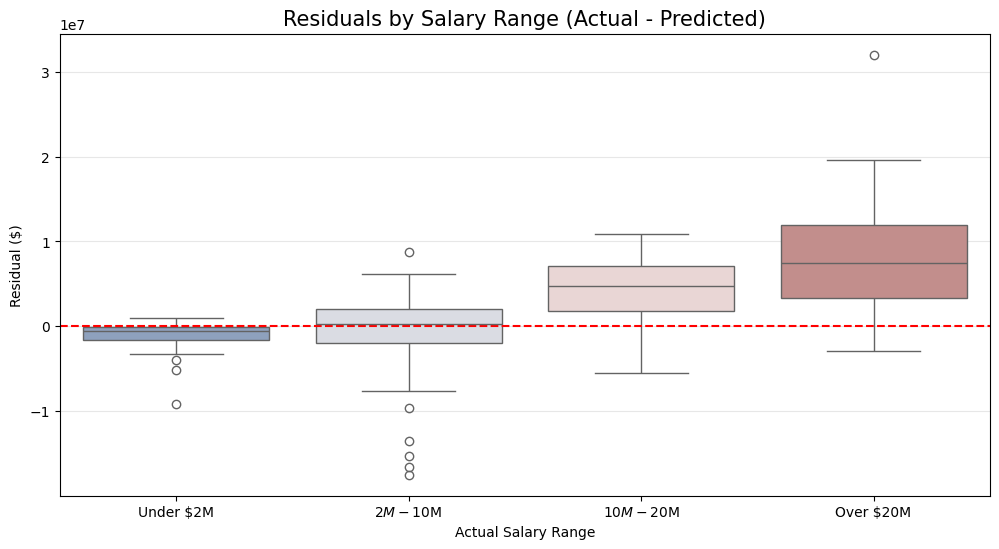

--- 年俸帯別・残差統計 ---
                      mean           std  count
Salary_Range                                   
Under $2M    -1.172502e+06  1.799681e+06     44
$2M-$10M     -1.138587e+06  5.694215e+06     46
$10M-$20M     4.125368e+06  4.498927e+06     18
Over $20M     8.213869e+06  7.647198e+06     29


/tmp/ipykernel_10626/4256285141.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  residual_stats = results_df.groupby('Salary_Range')['Residual'].agg(['mean', 'std', 'count'])


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 予測結果の集約
results_df = pd.DataFrame({
    'Actual': np.expm1(y_test),
    'Predicted': np.expm1(pred_rf)
})

# 残差（誤差）を計算
results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

# 2. 年俸帯別のグループ分け（4分位で分割、またはキリの良い数字で分割）
# ここでは分かりやすく金額でラベル付けします
bins = [0, 2000000, 10000000, 20000000, np.inf]
labels = ['Under $2M', '$2M-$10M', '$10M-$20M', 'Over $20M']
results_df['Salary_Range'] = pd.cut(results_df['Actual'], bins=bins, labels=labels)

# 3. 可視化：年俸帯別の残差分布
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, x='Salary_Range', y='Residual', palette='vlag')
plt.axhline(y=0, color='red', linestyle='--') # 誤差ゼロのライン

plt.title('Residuals by Salary Range (Actual - Predicted)', fontsize=15)
plt.ylabel('Residual ($)')
plt.xlabel('Actual Salary Range')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. 数値での確認
residual_stats = results_df.groupby('Salary_Range')['Residual'].agg(['mean', 'std', 'count'])
print("--- 年俸帯別・残差統計 ---")
print(residual_stats)

career_award_scoreで少し緩和されたものの、依然として高年俸帯では残差が大きいです。

In [41]:

results_df['Absolute_Error'] = results_df['Residual'].abs()
# 1. 予測結果と元のデータ（選手名や年齢など）をインデックスで結合
comparison_df = results_df.join(df_model_cleaned[['Name_Clean', 'Age', 'Team']])


# 2. 絶対誤差でソートしてトップ10を抽出
top_errors_named = comparison_df.sort_values('Absolute_Error', ascending=False).head(10)

# 3. 表示（見やすくするために列を整理）
print("--- 予測誤差が大きい選手トップ10 ---")
print(top_errors_named[['Name_Clean', 'Age', 'Team', 'Actual', 'Predicted', 'Residual']])

--- 予測誤差が大きい選手トップ10 ---
           Name_Clean  Age Team      Actual     Predicted      Residual
845        Will Smith   29  LAD  38550000.0  6.539542e+06  3.201046e+07
742      Alex Bregman   30  HOU  28500000.0  8.910837e+06  1.958916e+07
794       Jose Altuve   34  HOU  41000000.0  2.246234e+07  1.853766e+07
836     Shohei Ohtani   29  LAD   2000000.0  1.950711e+07 -1.750711e+07
737       Aaron Judge   32  NYY  40000000.0  2.317782e+07  1.682218e+07
761    Carlos Santana   38  MIN   5500000.0  2.205389e+07 -1.655389e+07
739     Adolis García   31  TEX   4750000.0  1.999685e+07 -1.524685e+07
820     Nolan Arenado   33  STL  24000000.0  9.209913e+06  1.479009e+07
745  Andrew McCutchen   37  PIT   5000000.0  1.851818e+07 -1.351818e+07
834      Seiya Suzuki   29  CHC  20000000.0  6.848414e+06  1.315159e+07


### shapによる分析

/tmp/ipykernel_10626/3231211132.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot")


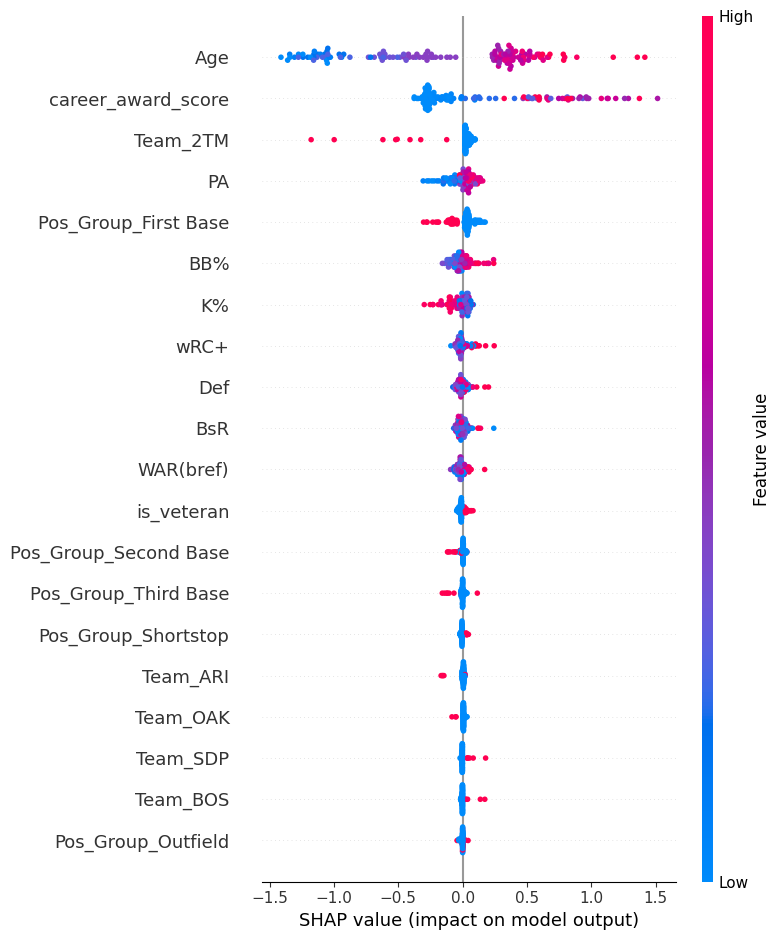

In [ ]:
import shap

# 1. Explainerの初期化
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot (全体の寄与度)
# どの特徴量が、予測値をプラス方向（高年俸）またはマイナス方向（低年俸）に押し上げたか
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

上の分析から以下のことがわかりました。

1 **年齢と契約制度の密接な関係**: 最も寄与度が高い Age は、FA権取得までの年数（サービスタイム）を反映しており、若手＝低賃金、ベテラン＝高賃金というMLB独自の硬直的な給与体系をモデルが正しく学習しています。

2 **「格」の数値化の成功**: 独自にエンジニアリングした career_award_score が、統計的なスタッツ（wRC+等）を凌駕する寄与度を示した。これは、MLBの大型契約（ＦＡになってからの契約）において「過去の実績・ブランド」が極めて重要であることを示唆しています。

3 **移籍選手の価値**: Team_2TM（シーズン中の移籍）が強い負の影響を与えていることから、年俸予測における強いマイナス信号として機能していることが明らかになりました。

4 **一塁手の価値**:一塁手は年俸が低く予測される傾向にあります。一塁手は打てて当たり前とされ、他の守備位置に比べて、市場価値が低いことが読み取れます。

--- 予測誤差が大きい選手トップ5のSHAP分析 ---

No.1: Will Smith
Actual: $38,550,000 / Predicted: $6,539,542


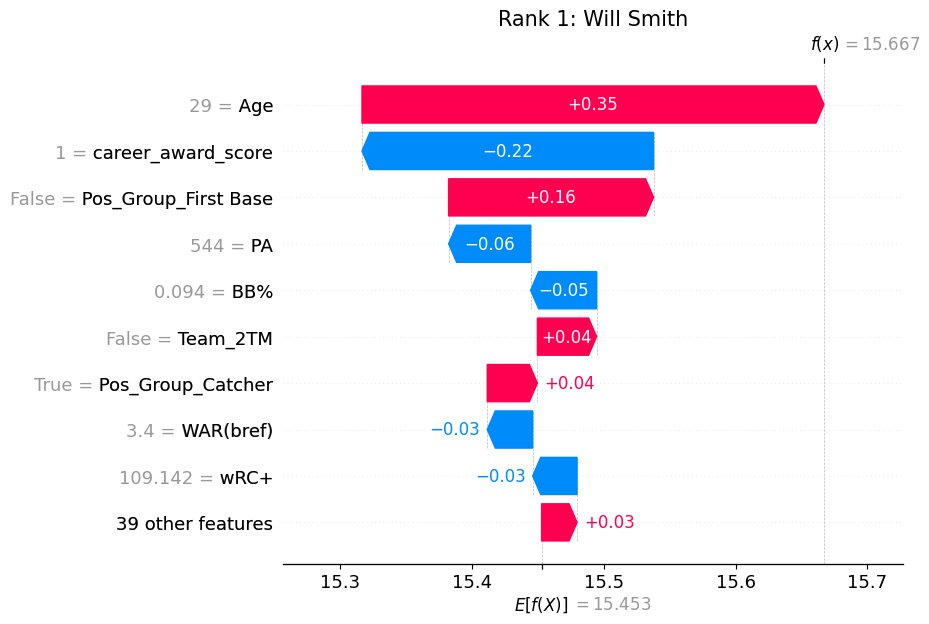


No.2: Alex Bregman
Actual: $28,500,000 / Predicted: $8,910,837


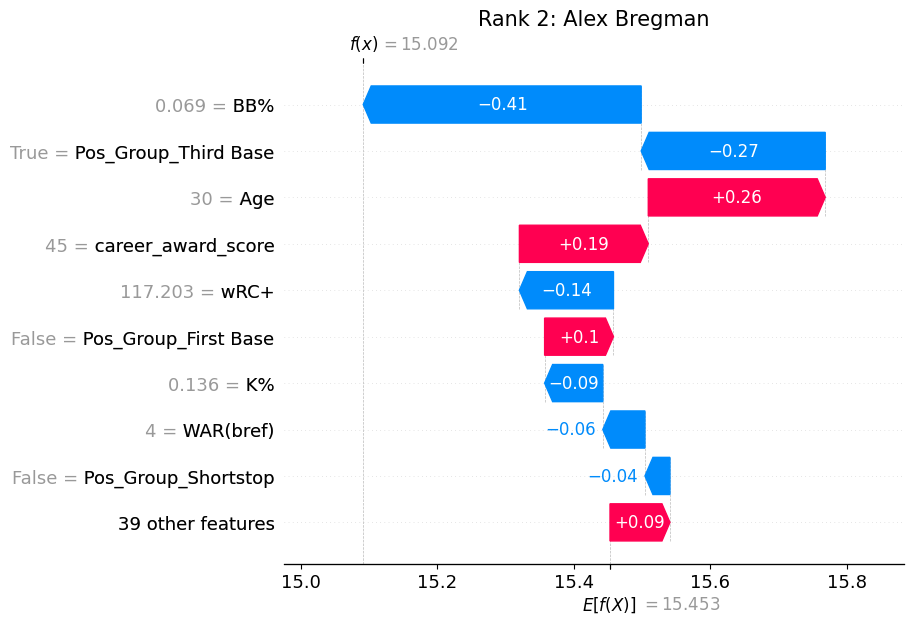


No.3: Jose Altuve
Actual: $41,000,000 / Predicted: $22,462,339


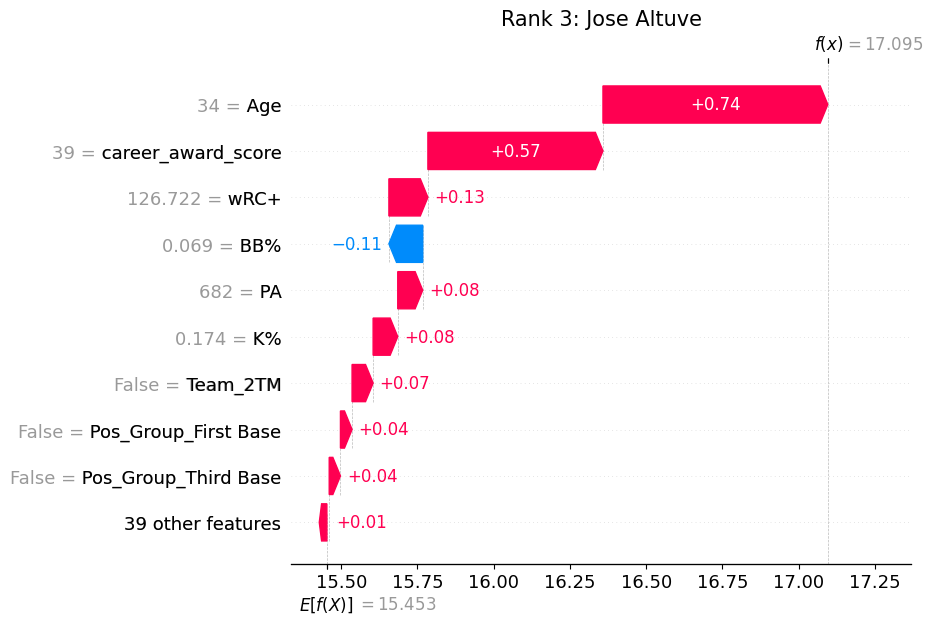


No.4: Shohei Ohtani
Actual: $2,000,000 / Predicted: $19,507,107


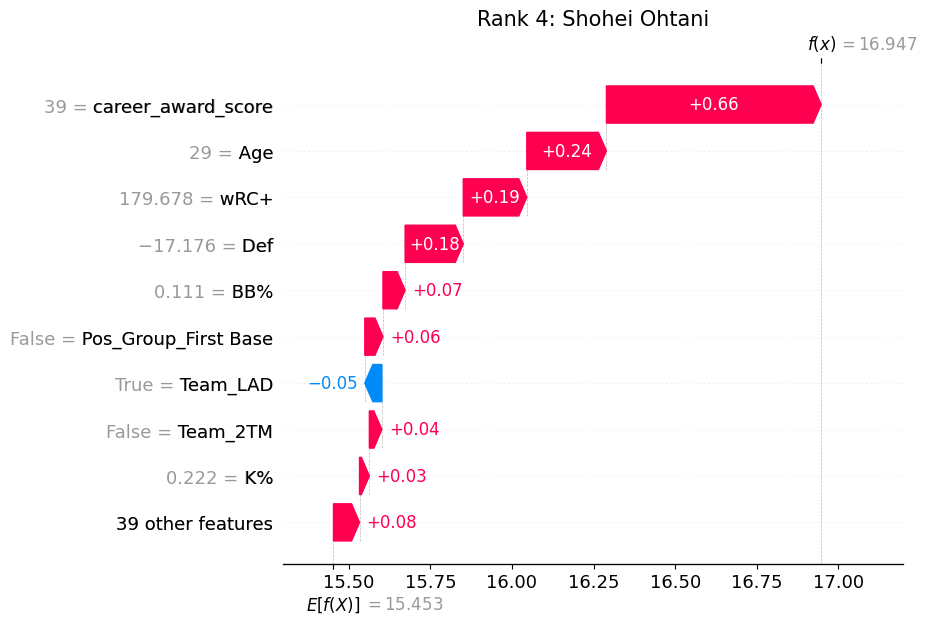


No.5: Aaron Judge
Actual: $40,000,000 / Predicted: $23,177,825


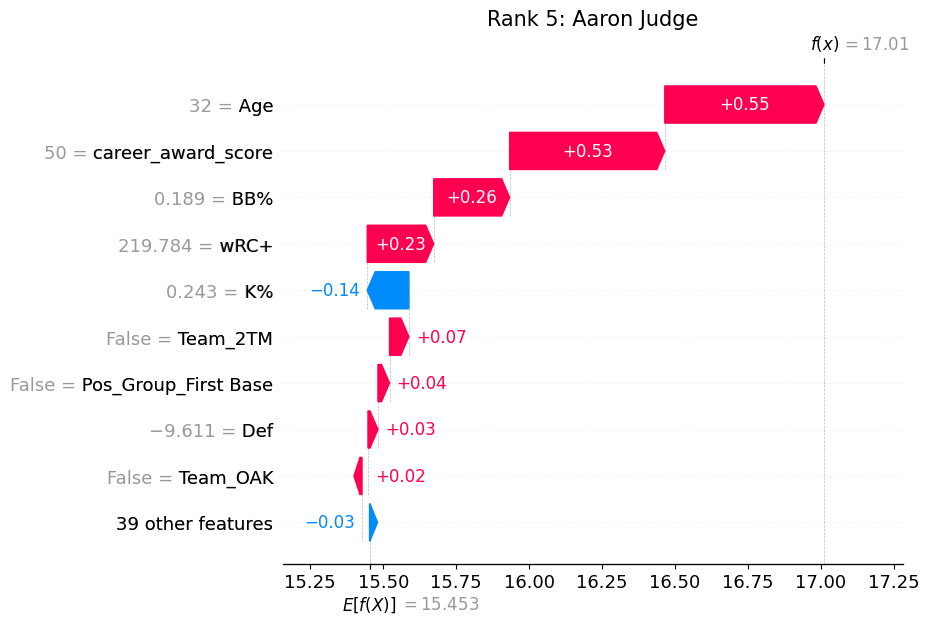


No.6: Carlos Santana
Actual: $5,500,000 / Predicted: $22,053,894


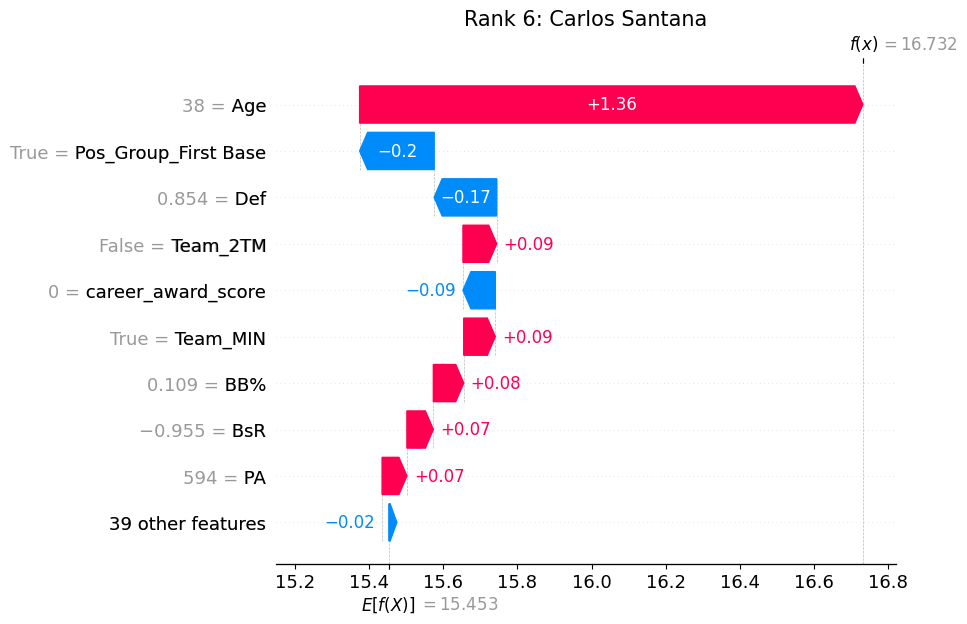


No.7: Adolis García
Actual: $4,750,000 / Predicted: $19,996,855


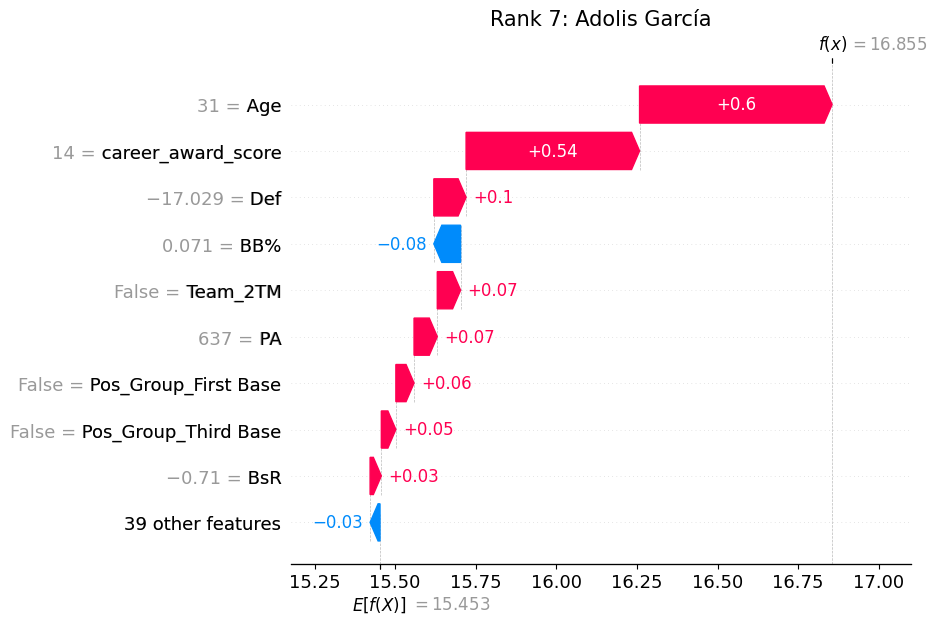


No.8: Nolan Arenado
Actual: $24,000,000 / Predicted: $9,209,913


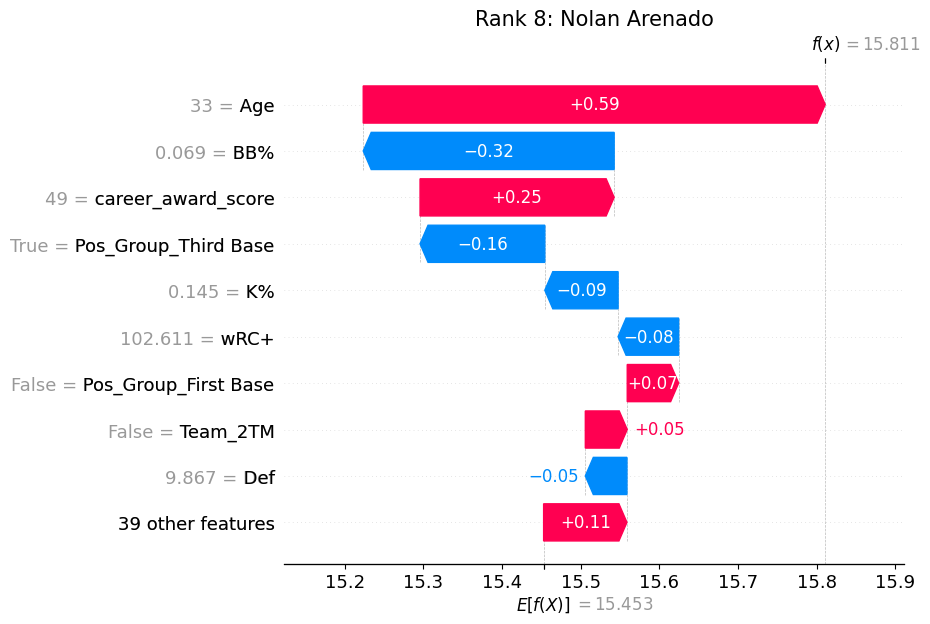


No.9: Andrew McCutchen
Actual: $5,000,000 / Predicted: $18,518,183


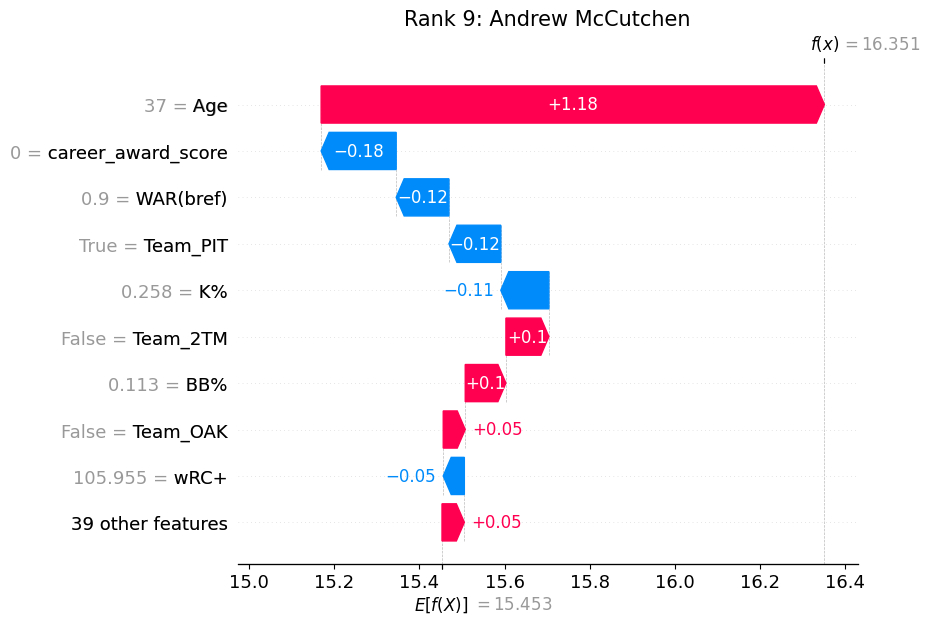


No.10: Seiya Suzuki
Actual: $20,000,000 / Predicted: $6,848,414


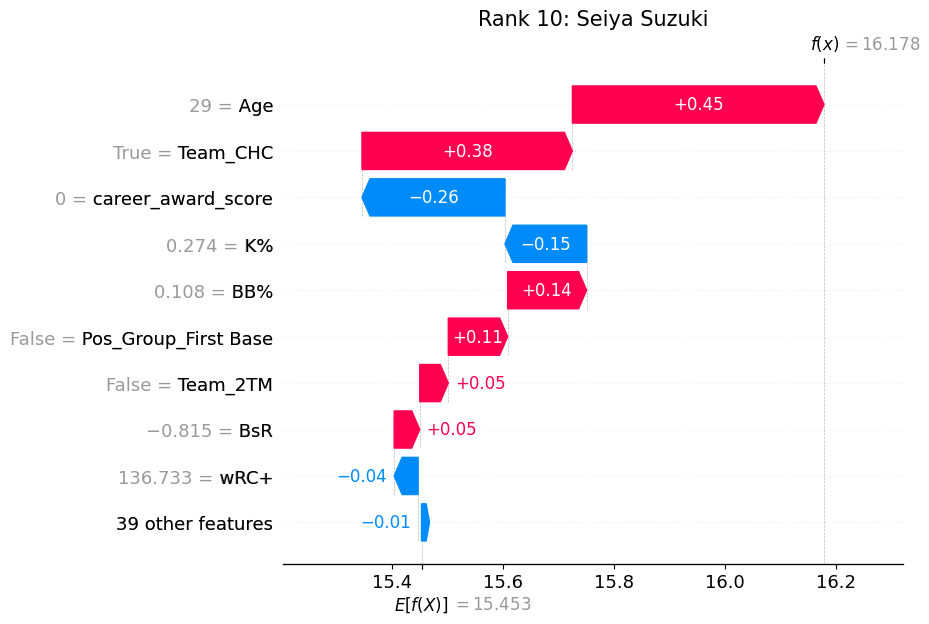

In [43]:
import matplotlib.pyplot as plt

# 1. SHAP値を計算（計算済みの場合はスキップしてください）
shap_exp = explainer(X_test)

# 2. 誤差上位5人をループで回す
print("--- 予測誤差が大きい選手トップ5のSHAP分析 ---")

for i in range(10):
    # 誤差ランキングから元のインデックスを取得
    original_idx = top_errors_named.index[i]

    # X_testの中での「何番目の位置か」を特定
    row_pos = X_test.index.get_loc(original_idx)

    # 表示用の情報を取得
    player_name = top_errors_named.loc[original_idx, 'Name_Clean']
    actual_val = top_errors_named.loc[original_idx, 'Actual']
    pred_val = top_errors_named.loc[original_idx, 'Predicted']

    # ログ出力
    print(f"\nNo.{i+1}: {player_name}")
    print(f"Actual: ${actual_val:,.0f} / Predicted: ${pred_val:,.0f}")

    # グラフの描画
    # waterfall内で直接タイトルを付けるのが難しいため、plt.titleを使用します
    shap.plots.waterfall(shap_exp[row_pos], show=False)
    plt.title(f"Rank {i+1}: {player_name}", fontsize=15)
    plt.show()

## 予測誤差が大きい選手トップ10選手についての分析
なぜ誤差が大きいのかの原因は主に２タイプに分かれます

１　**長期契約による年俸の固定** (Jose Altuve　Aaron Judge　Nolan Arenado　Alex Bregman)

スター選手で長期契約によりいずれの選手も高年俸で固定されており、career_award_scoreだけでは評価が不十分
   
２　**高年齢選手の衰え** (Carlos Santana　Andrew McCutchen)

   Age指標により年俸が高く見積もられているが、高年齢で衰えを加味し、実際には低価格で契約が結ばれています。


| 名前 | 考察 | 
|---|---|
| Will Smith| career_award_scoreで大きく下げられているが、捕手という役割ではこのスコアは伸ばしにくい。実際には複数年の高額契約を結んでいる。| 
| Adolis García | 遅咲きの選手であり、まだFA権を得られていないため予想より年俸が低い。 | 
| Seiya Suzuki | career_award_scoreで下げられているが、NPBでの活躍も考慮されて高額契約を結んでいる　|
|Shohei Ohtani | モデルの予想では打者としての評価だけなのに（投手としては考えらていない）実際の年俸よりも高く見積もってしまっている。これは、巨額の後払い契約のためである。


---
## 8. データ保存

分析セッションで蓄積された DuckDB（`mlb_analytics.duckdb`）を  
Google Drive の所定のパスへ同期して保存します。  
次回の継続開発時には、このファイルをローカルにコピーして再利用できます。

In [45]:
# DuckDBの内容をDriveに同期
con.close()
shutil.copy(LOCAL_DB_PATH, os.path.join(DRIVE_PATH, 'mlb_analytics.duckdb'))
print("Database synced to Google Drive.")

Database synced to Google Drive.
